# ♻️ IA Zéro Déchet — Notebook Colab
Assistant de tri, réparation et réutilisation avec données fictives réalistes.


In [ ]:
!pip install -q pandas scikit-learn numpy


In [1]:
import pandas as pd
from io import StringIO
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [3]:
csv_data = """objet,categorie,mots_cles,action_prioritaire,explication,reutilisation,score_ecologique
Téléphone brisé,électronique,"téléphone smartphone écran batterie chargeur",Réparer ou déposer en écocentre,"Les appareils électroniques contiennent des métaux rares et des composants pollua_nts.","Transformer en caméra de sécurité ou lecteur audio",92
Ordinateur portable lent,électronique,"ordinateur laptop pc lent batterie clavier",Réparer ou reconditionner,"Un ordinateur peut souvent être prolongé avec une mise à jour logicielle ou un changement de pièce.",Installer Linux léger ou donner à un organisme,90
Pile usagée,dangereux,"pile batterie aa aaa lithium",Point de dépôt spécialisé,"Les piles ne doivent pas aller aux déchets ordinaires.",Aucune réutilisation recommandée,95
Pot de yogourt,plastique,"pot yogourt plastique contenant alimentaire",Recycler si accepté localement,"Certains plastiques sont recyclables selon le numéro et la municipalité.",Utiliser pour semis ou rangement de vis,65
Bouteille de verre,verre,"bouteille verre pot bocal",Recycler ou réutiliser,"Le verre se recycle bien, mais la réutilisation évite du transport et de l’énergie.","Vase, contenant sec ou décoration",78
Vieux manteau,textile,"manteau vêtement textile tissu hiver",Donner ou réparer,"Les textiles ont un fort impact environnemental; il vaut mieux prolonger leur vie.","Patchwork, doublure ou don communautaire",86
T-shirt troué,textile,"t-shirt chandail trou coton vêtement",Réparer ou transformer,"Un textile abîmé peut devenir chiffon ou matière créative.","Chiffon, sac réutilisable ou couture",82
Marc de café,organique,"marc café filtre compost",Composter,"La matière organique produit du méthane en enfouissement.","Engrais doux, désodorisant ou exfoliant maison",91
Épluchures de légumes,organique,"épluchures légumes fruits restes cuisine",Composter,"Les résidus alimentaires sont précieux pour le compost.",Bouillon maison si propres,93
Carton de livraison,papier,"carton boîte livraison emballage",Réutiliser ou recycler,"Le carton peut servir plusieurs fois avant recyclage.","Rangement, déménagement ou bricolage",83
Livre ancien,papier,"livre roman manuel papier",Donner,"Un livre a une valeur culturelle et peut circuler longtemps.","Boîte à livres, bibliothèque ou organisme",87
Meuble abîmé,encombrant,"meuble chaise table bois armoire",Réparer ou donner,"Les encombrants peuvent souvent être restaurés.","Upcycling, peinture, transformation",84
Médicament expiré,dangereux,"médicament pilule sirop pharmacie",Retour en pharmacie,"Les médicaments ne doivent pas être jetés aux toilettes ni aux déchets.",Aucune réutilisation,98
Jouet en bon état,réutilisable,"jouet enfant jeu peluche",Donner,"Un objet encore fonctionnel devrait être transmis.","Don à une famille, école ou organisme",88
"""

df = pd.read_csv(StringIO(csv_data))
df.head()

,objet,categorie,mots_cles,action_prioritaire,explication,reutilisation,score_ecologique
0,Téléphone brisé,électronique,téléphone smartphone écran batterie chargeur,Réparer ou déposer en écocentre,Les appareils électroniques contiennent des mé...,Transformer en caméra de sécurité ou lecteur a...,92
1,Ordinateur portable lent,électronique,ordinateur laptop pc lent batterie clavier,Réparer ou reconditionner,Un ordinateur peut souvent être prolongé avec ...,Installer Linux léger ou donner à un organisme,90
2,Pile usagée,dangereux,pile batterie aa aaa lithium,Point de dépôt spécialisé,Les piles ne doivent pas aller aux déchets ord...,Aucune réutilisation recommandée,95
3,Pot de yogourt,plastique,pot yogourt plastique contenant alimentaire,Recycler si accepté localement,Certains plastiques sont recyclables selon le ...,Utiliser pour semis ou rangement de vis,65
4,Bouteille de verre,verre,bouteille verre pot bocal,Recycler ou réutiliser,"Le verre se recycle bien, mais la réutilisatio...","Vase, contenant sec ou décoration",78


In [13]:
display(df.head())

,objet,categorie,mots_cles,action_prioritaire,explication,reutilisation,score_ecologique
0,Téléphone brisé,électronique,téléphone smartphone écran batterie chargeur,Réparer ou déposer en écocentre,Les appareils électroniques contiennent des mé...,Transformer en caméra de sécurité ou lecteur a...,92
1,Ordinateur portable lent,électronique,ordinateur laptop pc lent batterie clavier,Réparer ou reconditionner,Un ordinateur peut souvent être prolongé avec ...,Installer Linux léger ou donner à un organisme,90
2,Pile usagée,dangereux,pile batterie aa aaa lithium,Point de dépôt spécialisé,Les piles ne doivent pas aller aux déchets ord...,Aucune réutilisation recommandée,95
3,Pot de yogourt,plastique,pot yogourt plastique contenant alimentaire,Recycler si accepté localement,Certains plastiques sont recyclables selon le ...,Utiliser pour semis ou rangement de vis,65
4,Bouteille de verre,verre,bouteille verre pot bocal,Recycler ou réutiliser,"Le verre se recycle bien, mais la réutilisatio...","Vase, contenant sec ou décoration",78


In [ ]:
def build_search_text(row):
    return f"{row['objet']} {row['categorie']} {row['mots_cles']} {row['action_prioritaire']}"

df['texte_recherche'] = df.apply(build_search_text, axis=1)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2))
matrix = vectorizer.fit_transform(df['texte_recherche'])

def recommander(description, top_k=3):
    query_vec = vectorizer.transform([description])
    similarities = cosine_similarity(query_vec, matrix).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]
    cols = ['objet','categorie','action_prioritaire','explication','reutilisation','score_ecologique']
    result = df.iloc[top_indices][cols].copy()
    result['similarite'] = [round(float(similarities[i]), 3) for i in top_indices]
    return result


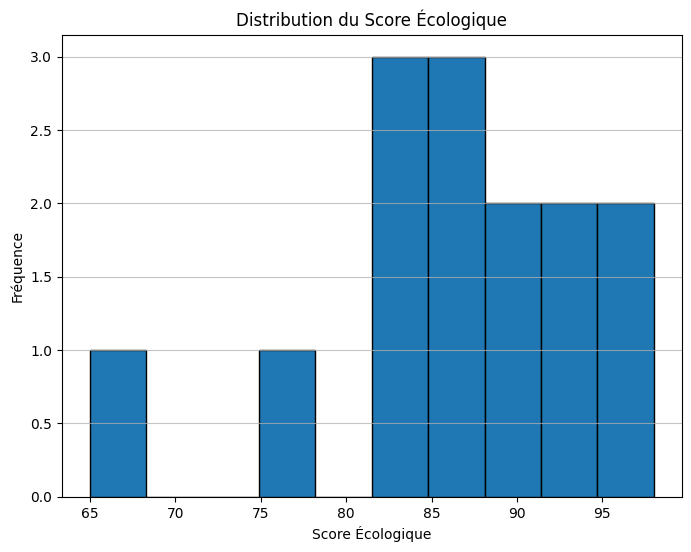

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(df['score_ecologique'], bins=10, edgecolor='black')
plt.title('Distribution du Score Écologique')
plt.xlabel('Score Écologique')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Score Écologique Moyen par Catégorie

In [9]:
average_score_per_category = df.groupby('categorie')['score_ecologique'].mean().sort_values(ascending=False)
display(average_score_per_category)

,score_ecologique
categorie,
dangereux,96.5
organique,92.0
électronique,91.0
réutilisable,88.0
papier,85.0
textile,84.0
encombrant,84.0
verre,78.0
plastique,65.0


### Visualisation du Score Écologique Moyen par Catégorie

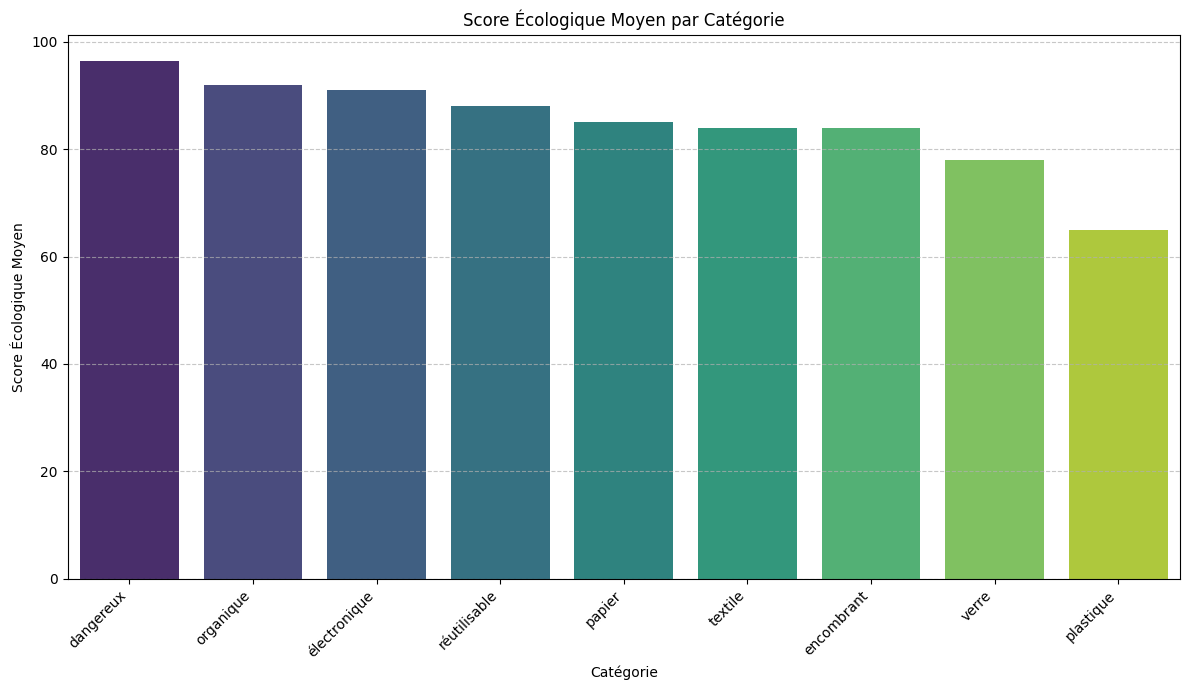

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=average_score_per_category.index, y=average_score_per_category.values, hue=average_score_per_category.index, palette='viridis', legend=False)
plt.title('Score Écologique Moyen par Catégorie')
plt.xlabel('Catégorie')
plt.ylabel('Score Écologique Moyen')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
recommander("vieux téléphone avec écran brisé")


,objet,categorie,action_prioritaire,explication,reutilisation,score_ecologique,similarite
0,Téléphone brisé,électronique,Réparer ou déposer en écocentre,Les appareils électroniques contiennent des mé...,Transformer en caméra de sécurité ou lecteur a...,92,0.411
5,Vieux manteau,textile,Donner ou réparer,Les textiles ont un fort impact environnementa...,"Patchwork, doublure ou don communautaire",86,0.110
14,Télévision,électronique,Réparer ou déposer en écocentre,Les télévisions contiennent des composants éle...,"Donner pour réparation, recycler les composant...",85,0.078


In [ ]:
recommander("manteau troué mais encore chaud")


## Pour aller plus loin
- Ajouter les règles de tri de votre municipalité.
- Ajouter une carte des écocentres.
- Ajouter une reconnaissance d’image.
- Déployer avec Streamlit Community Cloud ou Hugging Face Spaces.


### Test de la fonction de recommandation

In [16]:
# Filter the DataFrame for a specific category, for example, 'électronique'
electronique_items = df[df['categorie'] == 'électronique']

# Display the first few rows of the filtered DataFrame
display(electronique_items.head())

,objet,categorie,mots_cles,action_prioritaire,explication,reutilisation,score_ecologique
0,Téléphone brisé,électronique,téléphone smartphone écran batterie chargeur,Réparer ou déposer en écocentre,Les appareils électroniques contiennent des mé...,Transformer en caméra de sécurité ou lecteur a...,92
1,Ordinateur portable lent,électronique,ordinateur laptop pc lent batterie clavier,Réparer ou reconditionner,Un ordinateur peut souvent être prolongé avec ...,Installer Linux léger ou donner à un organisme,90


### Search by Keyword

To search the DataFrame for items containing a specific keyword in their `mots_cles` (keywords) column, you can use the `str.contains()` method. This is useful for quickly finding relevant items based on a text query.

In [17]:
# Define the keyword to search for
keyword = 'batterie'

# Filter the DataFrame to find rows where 'mots_cles' contains the keyword
# The 'case=False' argument makes the search case-insensitive
# The 'na=False' argument handles potential NaN values in the 'mots_cles' column
keyword_search_results = df[df['mots_cles'].str.contains(keyword, case=False, na=False)]

# Display the results
display(keyword_search_results)

,objet,categorie,mots_cles,action_prioritaire,explication,reutilisation,score_ecologique
0,Téléphone brisé,électronique,téléphone smartphone écran batterie chargeur,Réparer ou déposer en écocentre,Les appareils électroniques contiennent des mé...,Transformer en caméra de sécurité ou lecteur a...,92
1,Ordinateur portable lent,électronique,ordinateur laptop pc lent batterie clavier,Réparer ou reconditionner,Un ordinateur peut souvent être prolongé avec ...,Installer Linux léger ou donner à un organisme,90
2,Pile usagée,dangereux,pile batterie aa aaa lithium,Point de dépôt spécialisé,Les piles ne doivent pas aller aux déchets ord...,Aucune réutilisation recommandée,95


In [18]:
display(df.head())

,objet,categorie,mots_cles,action_prioritaire,explication,reutilisation,score_ecologique
0,Téléphone brisé,électronique,téléphone smartphone écran batterie chargeur,Réparer ou déposer en écocentre,Les appareils électroniques contiennent des mé...,Transformer en caméra de sécurité ou lecteur a...,92
1,Ordinateur portable lent,électronique,ordinateur laptop pc lent batterie clavier,Réparer ou reconditionner,Un ordinateur peut souvent être prolongé avec ...,Installer Linux léger ou donner à un organisme,90
2,Pile usagée,dangereux,pile batterie aa aaa lithium,Point de dépôt spécialisé,Les piles ne doivent pas aller aux déchets ord...,Aucune réutilisation recommandée,95
3,Pot de yogourt,plastique,pot yogourt plastique contenant alimentaire,Recycler si accepté localement,Certains plastiques sont recyclables selon le ...,Utiliser pour semis ou rangement de vis,65
4,Bouteille de verre,verre,bouteille verre pot bocal,Recycler ou réutiliser,"Le verre se recycle bien, mais la réutilisatio...","Vase, contenant sec ou décoration",78


In [4]:
def tester_recommandation(saisie_utilisateur):
    print(f"Recommandations pour '{saisie_utilisateur}':")
    display(recommander(saisie_utilisateur))
    print("\n" + "-"*50 + "\n")

In [30]:
tester_recommandation("bouteille de vin vide")

Recommandations pour 'bouteille de vin vide':


,objet,categorie,action_prioritaire,explication,reutilisation,score_ecologique,similarite
4,Bouteille de verre,verre,Recycler ou réutiliser,"Le verre se recycle bien, mais la réutilisatio...","Vase, contenant sec ou décoration",78,0.423
7,Marc de café,organique,Composter,La matière organique produit du méthane en enf...,"Engrais doux, désodorisant ou exfoliant maison",91,0.051
8,Épluchures de légumes,organique,Composter,Les résidus alimentaires sont précieux pour le...,Bouillon maison si propres,93,0.049



--------------------------------------------------



In [31]:
tester_recommandation("chaise cassée")

Recommandations pour 'chaise cassée':


,objet,categorie,action_prioritaire,explication,reutilisation,score_ecologique,similarite
11,Meuble abîmé,encombrant,Réparer ou donner,Les encombrants peuvent souvent être restaurés.,"Upcycling, peinture, transformation",84,0.221
13,Jouet en bon état,réutilisable,Donner,Un objet encore fonctionnel devrait être trans...,"Don à une famille, école ou organisme",88,0.000
14,Télévision,électronique,Réparer ou déposer en écocentre,Les télévisions contiennent des composants éle...,"Donner pour réparation, recycler les composant...",85,0.000



--------------------------------------------------



In [22]:
tester_recommandation("vieille télévision")

Recommandations pour 'vieille télévision':


,objet,categorie,action_prioritaire,explication,reutilisation,score_ecologique,similarite
13,Jouet en bon état,réutilisable,Donner,Un objet encore fonctionnel devrait être trans...,"Don à une famille, école ou organisme",88,0.0
12,Médicament expiré,dangereux,Retour en pharmacie,Les médicaments ne doivent pas être jetés aux ...,Aucune réutilisation,98,0.0
11,Meuble abîmé,encombrant,Réparer ou donner,Les encombrants peuvent souvent être restaurés.,"Upcycling, peinture, transformation",84,0.0



--------------------------------------------------



In [23]:
display(df['mots_cles'])

,mots_cles
0,téléphone smartphone écran batterie chargeur
1,ordinateur laptop pc lent batterie clavier
2,pile batterie aa aaa lithium
3,pot yogourt plastique contenant alimentaire
4,bouteille verre pot bocal
5,manteau vêtement textile tissu hiver
6,t-shirt chandail trou coton vêtement
7,marc café filtre compost
8,épluchures légumes fruits restes cuisine
9,carton boîte livraison emballage


In [19]:
def build_search_text(row):
    return f"{row['objet']} {row['categorie']} {row['mots_cles']} {row['action_prioritaire']}"

df['texte_recherche'] = df.apply(build_search_text, axis=1)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2))
matrix = vectorizer.fit_transform(df['texte_recherche'])

def recommander(description, top_k=3):
    query_vec = vectorizer.transform([description])
    similarities = cosine_similarity(query_vec, matrix).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]
    cols = ['objet','categorie','action_prioritaire','explication','reutilisation','score_ecologique']
    result = df.iloc[top_indices][cols].copy()
    result['similarite'] = [round(float(similarities[i]), 3) for i in top_indices]
    return result

In [20]:
display(df.head())

,objet,categorie,mots_cles,action_prioritaire,explication,reutilisation,score_ecologique,texte_recherche
0,Téléphone brisé,électronique,téléphone smartphone écran batterie chargeur,Réparer ou déposer en écocentre,Les appareils électroniques contiennent des mé...,Transformer en caméra de sécurité ou lecteur a...,92,Téléphone brisé électronique téléphone smartph...
1,Ordinateur portable lent,électronique,ordinateur laptop pc lent batterie clavier,Réparer ou reconditionner,Un ordinateur peut souvent être prolongé avec ...,Installer Linux léger ou donner à un organisme,90,Ordinateur portable lent électronique ordinate...
2,Pile usagée,dangereux,pile batterie aa aaa lithium,Point de dépôt spécialisé,Les piles ne doivent pas aller aux déchets ord...,Aucune réutilisation recommandée,95,Pile usagée dangereux pile batterie aa aaa lit...
3,Pot de yogourt,plastique,pot yogourt plastique contenant alimentaire,Recycler si accepté localement,Certains plastiques sont recyclables selon le ...,Utiliser pour semis ou rangement de vis,65,Pot de yogourt plastique pot yogourt plastique...
4,Bouteille de verre,verre,bouteille verre pot bocal,Recycler ou réutiliser,"Le verre se recycle bien, mais la réutilisatio...","Vase, contenant sec ou décoration",78,Bouteille de verre verre bouteille verre pot b...


### Adding a new item: Television

In [24]:
new_tv_data = {
    'objet': 'Télévision',
    'categorie': 'électronique',
    'mots_cles': 'télévision TV écran télé téléviseur image son',
    'action_prioritaire': 'Réparer ou déposer en écocentre',
    'explication': 'Les télévisions contiennent des composants électroniques qui doivent être traités spécialement pour éviter la pollution.',
    'reutilisation': 'Donner pour réparation, recycler les composants électroniques spécifiques',
    'score_ecologique': 85
}

df = pd.concat([df, pd.DataFrame([new_tv_data])], ignore_index=True)

display(df.tail())


,objet,categorie,mots_cles,action_prioritaire,explication,reutilisation,score_ecologique,texte_recherche
10,Livre ancien,papier,livre roman manuel papier,Donner,Un livre a une valeur culturelle et peut circu...,"Boîte à livres, bibliothèque ou organisme",87,Livre ancien papier livre roman manuel papier ...
11,Meuble abîmé,encombrant,meuble chaise table bois armoire,Réparer ou donner,Les encombrants peuvent souvent être restaurés.,"Upcycling, peinture, transformation",84,Meuble abîmé encombrant meuble chaise table bo...
12,Médicament expiré,dangereux,médicament pilule sirop pharmacie,Retour en pharmacie,Les médicaments ne doivent pas être jetés aux ...,Aucune réutilisation,98,Médicament expiré dangereux médicament pilule ...
13,Jouet en bon état,réutilisable,jouet enfant jeu peluche,Donner,Un objet encore fonctionnel devrait être trans...,"Don à une famille, école ou organisme",88,Jouet en bon état réutilisable jouet enfant je...
14,Télévision,électronique,télévision TV écran télé téléviseur image son,Réparer ou déposer en écocentre,Les télévisions contiennent des composants éle...,"Donner pour réparation, recycler les composant...",85,NaN


### Re-initializing and re-fitting the recommender after data update

In [25]:
def build_search_text(row):
    return f"{row['objet']} {row['categorie']} {row['mots_cles']} {row['action_prioritaire']}"

df['texte_recherche'] = df.apply(build_search_text, axis=1)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2))
matrix = vectorizer.fit_transform(df['texte_recherche'])

def recommander(description, top_k=3):
    query_vec = vectorizer.transform([description])
    similarities = cosine_similarity(query_vec, matrix).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]
    cols = ['objet','categorie','action_prioritaire','explication','reutilisation','score_ecologique']
    result = df.iloc[top_indices][cols].copy()
    result['similarite'] = [round(float(similarities[i]), 3) for i in top_indices]
    return result


### Re-testing the recommender with 'vieille télévision'

In [26]:
tester_recommandation("vieille télévision")


Recommandations pour 'vieille télévision':


,objet,categorie,action_prioritaire,explication,reutilisation,score_ecologique,similarite
14,Télévision,électronique,Réparer ou déposer en écocentre,Les télévisions contiennent des composants éle...,"Donner pour réparation, recycler les composant...",85,0.403
13,Jouet en bon état,réutilisable,Donner,Un objet encore fonctionnel devrait être trans...,"Don à une famille, école ou organisme",88,0.000
12,Médicament expiré,dangereux,Retour en pharmacie,Les médicaments ne doivent pas être jetés aux ...,Aucune réutilisation,98,0.000



--------------------------------------------------



In [27]:
tester_recommandation("batterie usagée")

Recommandations pour 'batterie usagée':


,objet,categorie,action_prioritaire,explication,reutilisation,score_ecologique,similarite
2,Pile usagée,dangereux,Point de dépôt spécialisé,Les piles ne doivent pas aller aux déchets ord...,Aucune réutilisation recommandée,95,0.260
0,Téléphone brisé,électronique,Réparer ou déposer en écocentre,Les appareils électroniques contiennent des mé...,Transformer en caméra de sécurité ou lecteur a...,92,0.101
1,Ordinateur portable lent,électronique,Réparer ou reconditionner,Un ordinateur peut souvent être prolongé avec ...,Installer Linux léger ou donner à un organisme,90,0.093



--------------------------------------------------



In [28]:
tester_recommandation("vieux smartphone")

Recommandations pour 'vieux smartphone':


,objet,categorie,action_prioritaire,explication,reutilisation,score_ecologique,similarite
5,Vieux manteau,textile,Donner ou réparer,Les textiles ont un fort impact environnementa...,"Patchwork, doublure ou don communautaire",86,0.151
0,Téléphone brisé,électronique,Réparer ou déposer en écocentre,Les appareils électroniques contiennent des mé...,Transformer en caméra de sécurité ou lecteur a...,92,0.150
14,Télévision,électronique,Réparer ou déposer en écocentre,Les télévisions contiennent des composants éle...,"Donner pour réparation, recycler les composant...",85,0.000



--------------------------------------------------



In [21]:
 %whos

Variable                     Type               Data/Info
---------------------------------------------------------
StringIO                     type               <class '_io.StringIO'>
TfidfVectorizer              type               <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
average_score_per_category   Series             categorie\ndangereux     <...>cologique, dtype: float64
build_search_text            function           <function build_search_text at 0x7a65bc0c6b60>
cosine_similarity            function           <function cosine_similarity at 0x7a65bcb78a40>
csv_data                     str                objet,categorie,mots_cles<...> école ou organisme",88\n
df                           DataFrame                                 ob<...>able jouet enfant je...  
electronique_items           DataFrame                                obj<...>nisme                90  
keyword                      str                batterie
keyword_search_results       DataFrame        